In [1]:
import uproot
import pandas as pd
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import mplhep as hep
import os
import joblib
import json
import warnings
from xgboost import XGBClassifier
from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold, learning_curve)
from sklearn.metrics import (roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score)

In [5]:
signal_path = "/home/tandrade/Flavour_Anomalies/Data/NonResonant_final_merged.root"
bg_path     = "/home/tandrade/Flavour_Anomalies/Data/Data_final_merged.root"
tree_name   = "tree_ML"

In [6]:
features = [
    'BToTrkTrkMuMu_l_xy_good',
    'BToTrkTrkMuMu_l_xy_unc_good',
    
    'BToTrkTrkMuMu_dca_good',
    'BToTrkTrkMuMu_dcaErr_good',

    'BToTrkTrkMuMu_trk1_dca_good',
    'BToTrkTrkMuMu_trk1_dcaErr_good',
    
    'BToTrkTrkMuMu_trk2_dca_good',
    'BToTrkTrkMuMu_trk2_dcaErr_good',
    
    'BToTrkTrkMuMu_fit_ditrack_mass_Kpi_good',
    'BToTrkTrkMuMu_fit_pt_good',
    'BToTrkTrkMuMu_fit_cos2D_good',
    'BToTrkTrkMuMu_svprob_good'
]

cut_features = [
    'MuMu_mass_good', 
    'BToTrkTrkMuMu_fit_mass_Kpi_good',
    'HLT_DoubleMu4_3_LowMass'
]

In [7]:
signal_file = uproot.open(signal_path)[tree_name]
background_file = uproot.open(bg_path)[tree_name]

In [8]:
cols_to_load = features + cut_features

signal_ak = signal_file.arrays(cols_to_load, library="ak")
background_ak = background_file.arrays(cols_to_load, library="ak")

In [9]:
signal_df = ak.to_dataframe(signal_ak)
background_df = ak.to_dataframe(background_ak)

In [10]:
sig_pairs = [
    ('BToTrkTrkMuMu_l_xy_good', 'BToTrkTrkMuMu_l_xy_unc_good', 'BToTrkTrkMuMu_l_xy_sig_good'),
    ('BToTrkTrkMuMu_dca_good', 'BToTrkTrkMuMu_dcaErr_good', 'BToTrkTrkMuMu_dca_sig_good'),
    ('BToTrkTrkMuMu_trk1_dca_good', 'BToTrkTrkMuMu_trk1_dcaErr_good', 'BToTrkTrkMuMu_trk1_dca_sig_good'),
    ('BToTrkTrkMuMu_trk2_dca_good', 'BToTrkTrkMuMu_trk2_dcaErr_good', 'BToTrkTrkMuMu_trk2_dca_sig_good')
]

for val, err, sig in sig_pairs:
    signal_df[sig] = signal_df[val] / signal_df[err]

for val, err, sig in sig_pairs:
    background_df[sig] = background_df[val] / background_df[err]

In [11]:
signal_df["label"] = 1
background_df["label"] = 0

In [13]:
df = pd.concat([signal_df, background_df], ignore_index=True)

cut_mass_B = (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] > 5.0) & (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] < 5.6)
cut_mass_MuMu = ( ((df['MuMu_mass_good'] > 1.0) & (df['MuMu_mass_good'] < 2.9)) | ((df['MuMu_mass_good'] > 4.0) & (df['MuMu_mass_good'] < 4.8)) )
cut_trigger = df['HLT_DoubleMu4_3_LowMass'] == 1

is_signal_label = (df['label'] == 1)
signal_region_cut = (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] > 5.133542769) & (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] < 5.416657231)
keep_signal = is_signal_label & signal_region_cut

is_bkg_label = (df['label'] == 0)
left_band = (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] > 5.0) & (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] <= 5.133542769)
right_band = (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] >= 5.416657231) & (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] < 5.6)
keep_bkg = is_bkg_label & (left_band | right_band)

final_selection_mask = (keep_signal | keep_bkg) & cut_mass_MuMu & cut_trigger
df_cut = df[final_selection_mask]

In [14]:
final_cols = features + ['label']
df_final = df_cut[final_cols].copy()
df = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

In [15]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna()

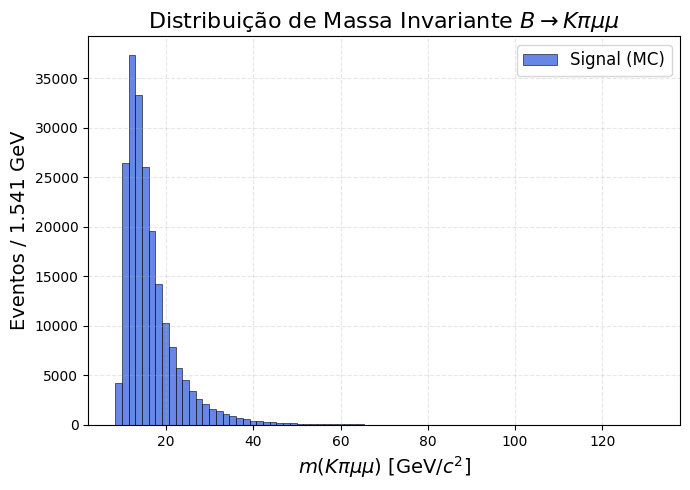

In [16]:
plt.figure(figsize=(7, 5))

# Criando o histograma
counts, bins, _ = plt.hist(df[df['label'] == 0]["BToTrkTrkMuMu_fit_pt_good"], 
                           bins=80, 
                           color='royalblue', 
                           alpha=0.8,            # Transparência
                           edgecolor='black',    # Contorno das barras
                           linewidth=0.5,        # Espessura do contorno
                           label='Signal (MC)')  # Label updated since we filtered for label=1

# Decoração do gráfico (Estilo Física)
plt.title(r'Distribuição de Massa Invariante $B \to K \pi \mu \mu$', fontsize=16)

# ERROR FIX: Updated X-axis label to match the variable being plotted (B mass, not dimuon)
plt.xlabel(r'$m(K \pi \mu \mu)$ [GeV/$c^2$]', fontsize=14)

# Eixo Y normalizado pela largura do bin
plt.ylabel(f'Eventos / {(bins[1]-bins[0]):.3f} GeV', fontsize=14) 

# Adiciona grid e legenda
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(fontsize=12)

# Exibe
plt.tight_layout()
plt.show()

In [17]:
X = df[features]
y = df["label"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
num_background_train = (y_train == 0).sum()
num_signal_train = (y_train == 1).sum()
scale_pos_weight_train = num_background_train / num_signal_train if num_signal_train > 0 else 1

print(num_background_train, num_signal_train)

144887 111706


In [19]:
bdt = XGBClassifier(
    use_label_encoder=False,
    eval_metric="auc",
    verbosity=0,
    random_state=42
)

In [20]:
xgb_param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

In [21]:
grid_search = GridSearchCV(
    estimator=bdt,
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='auc', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.8, 1.0],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 150],
                         'subsample': [0.6, 0.8, 1.0]},
             return_train_score=True, scoring='roc_auc', verbose=1)

In [22]:
final_bdt = grid_search.best_estimator_


Executando validação cruzada de 5 folds...
  Fold 1: AUC = 0.9875
  Fold 2: AUC = 0.9878
  Fold 3: AUC = 0.9878
  Fold 4: AUC = 0.9874
  Fold 5: AUC = 0.9867

Curvas ROC salvas: kfold_roc_curves.png


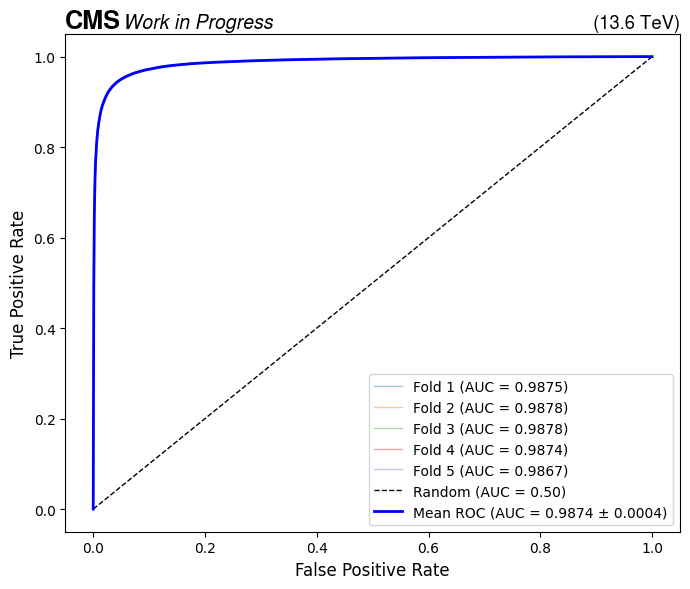

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tprs = []
aucs = []
# Mantive 1000 pontos para boa resolução
mean_fpr = np.linspace(0, 1, 1000)

fig, ax = plt.subplots(figsize=(7, 6))

print("\nExecutando validação cruzada de 5 folds...")

for i, (train_index, val_index) in enumerate(cv.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # Recalcular scale_pos_weight
    num_bg_fold = (y_train_fold == 0).sum()
    num_sig_fold = (y_train_fold == 1).sum()
    scale_pos_weight_fold = num_bg_fold / num_sig_fold if num_sig_fold > 0 else 1
    
    # Treinar
    fold_bdt = XGBClassifier(
        **grid_search.best_params_,
        use_label_encoder=False,
        eval_metric="auc",
        verbosity=0,
        scale_pos_weight=scale_pos_weight_fold,
        random_state=42
    )
    
    fold_bdt.fit(X_train_fold, y_train_fold)
    
    # Previsões
    y_val_proba = fold_bdt.predict_proba(X_val_fold)[:, 1]
    
    # ROC
    fpr, tpr, _ = roc_curve(y_val_fold, y_val_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Interpolar
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    
    # Plot individual
    ax.plot(fpr, tpr, alpha=0.4, lw=1, label=f'Fold {i+1} (AUC = {roc_auc:.4f})')
    print(f"  Fold {i+1}: AUC = {roc_auc:.4f}")

# Plotar linha random
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)', lw=1)

# Calcular média e desvio padrão
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0

# --- MELHORIA: Usar a média dos valores de AUC calculados ---
mean_auc = np.mean(aucs) # Mais preciso que calcular a área da curva média
std_auc = np.std(aucs)
std_tpr = np.std(tprs, axis=0)

# Plotar ROC média
ax.plot(mean_fpr, mean_tpr, 'b', 
        label=f'Mean ROC (AUC = {mean_auc:.4f} ± {std_auc:.4f})', 
        lw=2)

# Adicionar intervalo de confiança
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(mean_fpr, tprs_lower, tprs_upper, alpha=0.2, color='grey')

# Configurar gráfico
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("", fontsize=14)

# --- AQUI ESTÁ A MUDANÇA ---
# Mudei de 'small' para 'x-small'. 
# Se ainda achar grande, pode colocar um número, ex: fontsize=10
ax.legend(loc="lower right", fontsize = 10) 

#ax.grid(True, alpha=0.3)
hep.cms.label("Work in Progress", ax=ax,fontsize=14, com=13.6, data=True)

plt.tight_layout()
plt.savefig("Plots/kfold_roc_curves.png", dpi=100, bbox_inches='tight')
print(f"\nCurvas ROC salvas: kfold_roc_curves.png")
plt.show()
plt.close()


Calculando métricas...
Curvas ROC/PRC salvas: final_roc_prc_curves_TRAIN_vs_TEST.png


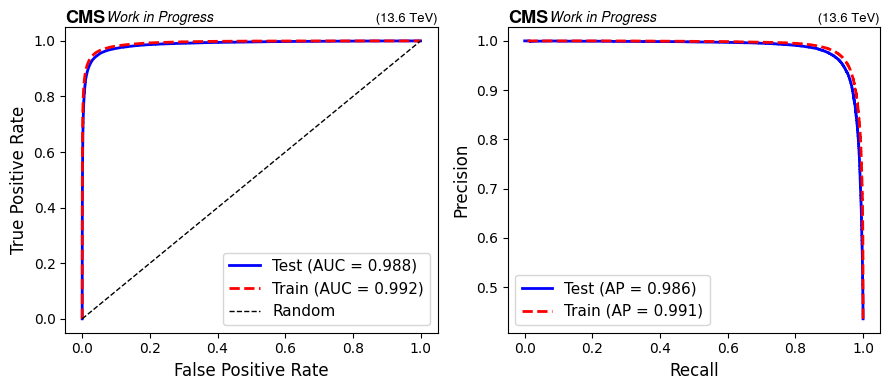

In [24]:
# Previsões no teste
y_test_proba = final_bdt.predict_proba(X_test)[:, 1]
y_test_pred = final_bdt.predict(X_test)

# Previsões no treino (para comparação)
y_train_proba = final_bdt.predict_proba(X_train)[:, 1]

# Calcular métricas
print("\nCalculando métricas...")

# ROC Curves
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
roc_auc_test = auc(fpr_test, tpr_test)

fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
roc_auc_train = auc(fpr_train, tpr_train)

# Precision-Recall Curves
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba)
prc_auc_test = average_precision_score(y_test, y_test_proba)

precision_train, recall_train, _ = precision_recall_curve(y_train, y_train_proba)
prc_auc_train = average_precision_score(y_train, y_train_proba)

# Plot ROC e PRC lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

# ROC Curve
ax1.plot(fpr_test, tpr_test, label=f"Test (AUC = {roc_auc_test:.3f})", 
         color="blue", lw=2)
ax1.plot(fpr_train, tpr_train, label=f"Train (AUC = {roc_auc_train:.3f})", 
         color="red", linestyle='--', lw=2)
ax1.plot([0, 1], [0, 1], "k--", label='Random', lw=1)
ax1.set_xlabel("False Positive Rate", fontsize=12)
ax1.set_ylabel("True Positive Rate", fontsize=12)
#ax1.set_title("ROC Curves", fontsize=14)
ax1.legend(loc="lower right", fontsize=11)
#ax1.grid(True, alpha=0.3)
hep.cms.label("Work in Progress", ax=ax1, com=13.6, data=True)

# Precision-Recall Curve
ax2.plot(recall_test, precision_test, label=f"Test (AP = {prc_auc_test:.3f})", 
         color="blue", lw=2)
ax2.plot(recall_train, precision_train, label=f"Train (AP = {prc_auc_train:.3f})", 
         color="red", linestyle='--', lw=2)
ax2.set_xlabel("Recall", fontsize=12)
ax2.set_ylabel("Precision", fontsize=12)
#ax2.set_title("Precision-Recall Curves", fontsize=14)
ax2.legend(loc="lower left", fontsize=11)
#ax2.grid(True, alpha=0.3)
hep.cms.label("Work in Progress", ax=ax2, com=13.6, data=True)

plt.tight_layout()
plt.savefig("Plots/final_roc_prc_curves_TRAIN_vs_TEST.png", dpi=100, bbox_inches='tight')
print(f"Curvas ROC/PRC salvas: final_roc_prc_curves_TRAIN_vs_TEST.png")
plt.show()
plt.close()

Matriz de confusão salva: final_confusion_matrix_TEST.png


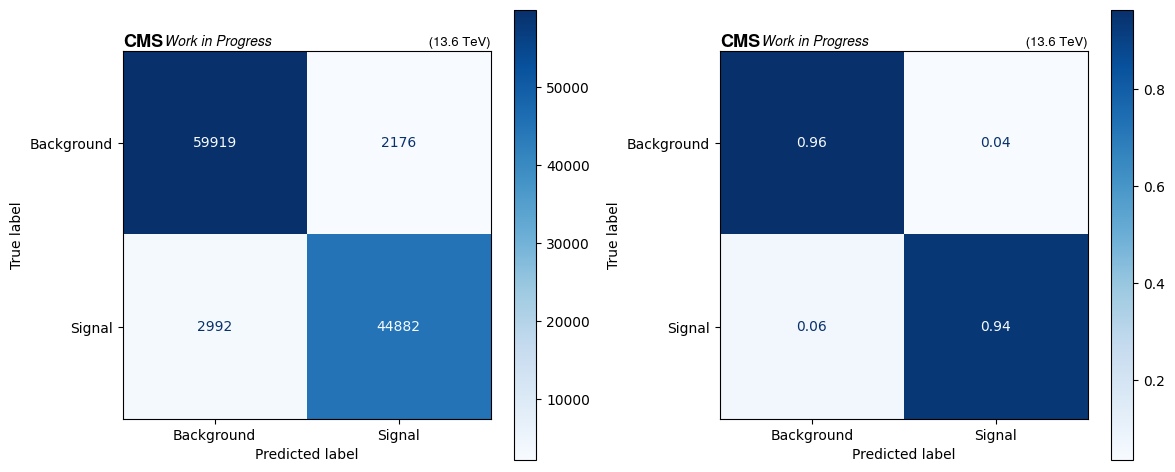


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

  Background     0.9524    0.9650    0.9587     62095
      Signal     0.9538    0.9375    0.9456     47874

    accuracy                         0.9530    109969
   macro avg     0.9531    0.9512    0.9521    109969
weighted avg     0.9530    0.9530    0.9530    109969

Accuracy: 0.9530
F1-Score: 0.9456


In [25]:
# Matriz de confusão normalizada
cm = confusion_matrix(y_test, y_test_pred)
cm_norm = confusion_matrix(y_test, y_test_pred, normalize='true')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Matriz absoluta
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=["Background", "Signal"])
disp1.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title("", fontsize=14)

# Matriz normalizada
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, 
                              display_labels=["Background", "Signal"])
disp2.plot(ax=ax2, cmap='Blues', values_format='.2f')
ax2.set_title("", fontsize=14)

hep.cms.label("Work in Progress", ax=ax1, com=13.6, data=True, loc=0)
hep.cms.label("Work in Progress", ax=ax2, com=13.6, data=True, loc=0)

plt.tight_layout()
plt.savefig("Plots/final_confusion_matrix_TEST.png", dpi=100, bbox_inches='tight')
print(f"Matriz de confusão salva: final_confusion_matrix_TEST.png")
plt.show()
plt.close()

# Report de classificação
print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred, 
                           target_names=['Background', 'Signal'],
                           digits=4))

print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_test_pred):.4f}")

Importância das features (weight) salva: feature_importances_weight.png


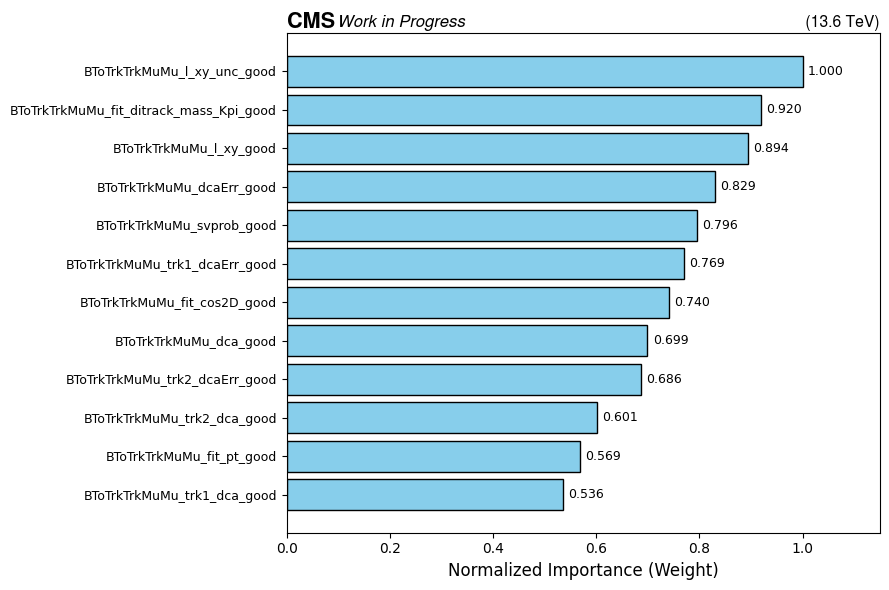

In [26]:
# Plotar apenas o feature importance normalizado pelo weight
imp_type = 'weight'  # Selecionar apenas o tipo weight

fig, ax = plt.subplots(figsize=(9, 6))  # Ajustei o tamanho para um único gráfico

try:
    # Obter importância pelo weight
    importance = final_bdt.get_booster().get_score(importance_type=imp_type)
    imp_df = pd.DataFrame.from_dict(importance, orient='index', 
                                   columns=[imp_type]).reindex(features).fillna(0)
    
    # Normalizar
    imp_df['Normalized'] = imp_df[imp_type] / imp_df[imp_type].max()
    imp_df = imp_df.sort_values('Normalized', ascending=True)
    
    # Plot
    bars = ax.barh(imp_df.index, imp_df['Normalized'], color='skyblue', edgecolor='black')
    
    # Adicionar valores
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
               f'{width:.3f}', va='center', color='black', fontsize=9)
    
    ax.set_xlabel("Normalized Importance (Weight)", fontsize=12)
    ax.set_title(" ", fontsize=14)
    ax.set_xlim(right=imp_df['Normalized'].max() * 1.15)
    #ax.grid(True, alpha=0.3, axis='x')
    ax.tick_params(axis='y', labelsize=9)
    
    # Adicionar label CMS
    hep.cms.label("Work in Progress", ax=ax, com=13.6, data=True, fontsize=12)
    
except Exception as e:
    ax.text(0.5, 0.5, f'Weight importance not available\n{str(e)}', 
           ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title(" ", fontsize=14)

plt.tight_layout()
plt.savefig('Plots/feature_importances_weight.png', dpi=100, bbox_inches='tight')
print(f"Importância das features (weight) salva: feature_importances_weight.png")
plt.show()
plt.close()

Plot salvo como overtraining_check.png


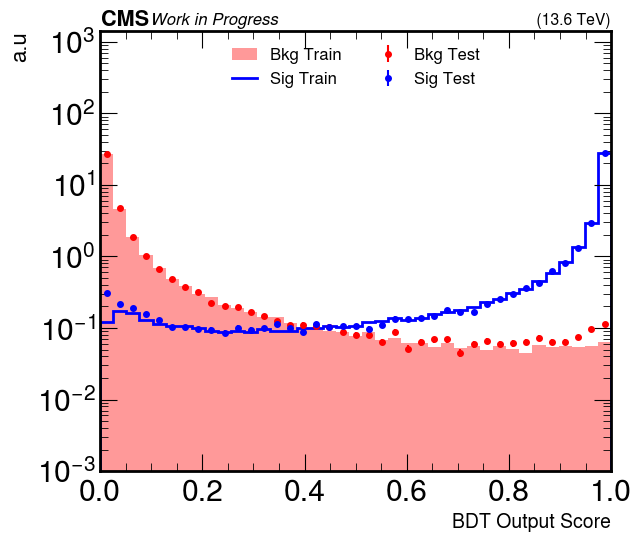

In [27]:
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np
from scipy.stats import ks_2samp

plt.style.use(hep.style.ROOT)

# 1. Obter as probabilidades (garantindo que não haja NaNs)
y_probs_train = final_bdt.predict_proba(X_train)[:, 1]
y_probs_test = final_bdt.predict_proba(X_test)[:, 1]

# 2. Separar Sinal e Background
sig_train = y_probs_train[y_train == 1]
bkg_train = y_probs_train[y_train == 0]
sig_test = y_probs_test[y_test == 1]
bkg_test = y_probs_test[y_test == 0]

# 3. Calcular KS Test
ks_sig = ks_2samp(sig_train, sig_test)
ks_bkg = ks_2samp(bkg_train, bkg_test)

# 4. Configurar Plot
fig, ax = plt.subplots(figsize=(7, 6))
bins = np.linspace(0, 1, 40)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# --- BACKGROUND (Vermelho) ---

# A) Treino: Calcular histograma no Numpy PRIMEIRO
# density=True aqui retorna os valores já normalizados
h_bkg_train, _ = np.histogram(bkg_train, bins=bins, density=True)

hep.histplot(h_bkg_train, bins=bins, 
             ax=ax, color='red', alpha=0.4, histtype='fill', 
             label='Bkg Train')

# B) Teste: Pontos com erro
h_bkg_test_counts, _ = np.histogram(bkg_test, bins=bins) # Contagens puras para o erro
h_bkg_test_dens, _   = np.histogram(bkg_test, bins=bins, density=True) # Densidade para o plot

# Cálculo do erro na escala de densidade:
# Erro_contagem = sqrt(N)
# Fator_escala = Densidade / Contagem
# Erro_densidade = sqrt(N) * (Densidade / N)
scale_bkg = np.divide(h_bkg_test_dens, h_bkg_test_counts, out=np.zeros_like(h_bkg_test_dens), where=h_bkg_test_counts!=0)
error_bkg = np.sqrt(h_bkg_test_counts) * scale_bkg

ax.errorbar(bin_centers, h_bkg_test_dens, yerr=error_bkg, 
            fmt='o', color='red', markersize=4, label=f'Bkg Test')


# --- SIGNAL (Azul) ---

# A) Treino
h_sig_train, _ = np.histogram(sig_train, bins=bins, density=True)

hep.histplot(h_sig_train, bins=bins, 
             ax=ax, color='blue', linewidth=2, histtype='step', 
             label='Sig Train')

# B) Teste
h_sig_test_counts, _ = np.histogram(sig_test, bins=bins)
h_sig_test_dens, _   = np.histogram(sig_test, bins=bins, density=True)

scale_sig = np.divide(h_sig_test_dens, h_sig_test_counts, out=np.zeros_like(h_sig_test_dens), where=h_sig_test_counts!=0)
error_sig = np.sqrt(h_sig_test_counts) * scale_sig

ax.errorbar(bin_centers, h_sig_test_dens, yerr=error_sig, 
            fmt='o', color='blue', markersize=4, label=f'Sig Test')

# --- Decoração ---
ax.set_yscale('log')
# Definir limites seguros para log
max_y = max(h_sig_train.max(), h_bkg_train.max())
ax.set_ylim(bottom=1e-3, top=max_y * 50) 
ax.set_xlim(0, 1)

ax.set_xlabel("BDT Output Score", fontsize=14)
ax.set_ylabel("a.u", fontsize=16)
ax.legend(loc='upper center', fontsize=12, ncol=2)

hep.cms.label("Work in Progress", ax=ax, com=13.6, data=True, fontsize=12)

plt.tight_layout()
plt.savefig("Plots/overtraining_check.png")
print("Plot salvo como overtraining_check.png")
plt.show()

Learning curves salvas: learning_curves.png


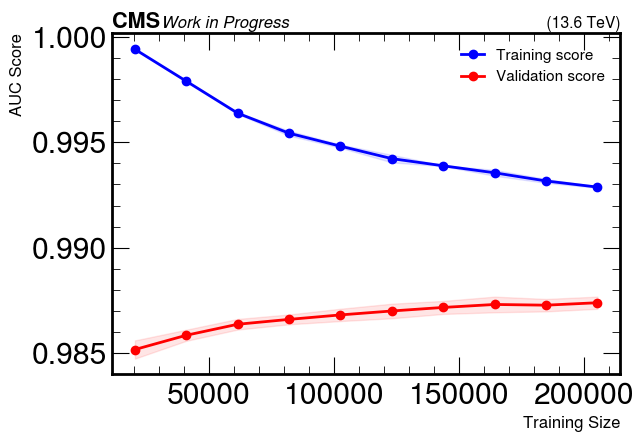

In [28]:
train_sizes, train_scores, val_scores = learning_curve(
    final_bdt, X_train, y_train,
    cv=5, scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

fig, ax = plt.subplots(figsize=(7, 5))

# Calcular médias e desvios
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plotar
ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score', lw=2)
ax.plot(train_sizes, val_mean, 'o-', color='red', label='Validation score', lw=2)

# Adicionar intervalos de confiança
ax.fill_between(train_sizes, 
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.1, color='blue')
ax.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.1, color='red')

ax.set_xlabel('Training Size', fontsize=12)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_title(' ', fontsize=14)
ax.legend(loc='best', fontsize=11)
#ax.grid(True, alpha=0.3)
hep.cms.label("Work in Progress", ax=ax, com=13.6, data=True, fontsize=12)

plt.tight_layout()
plt.savefig('Plots/learning_curves.png', dpi=100, bbox_inches='tight')
print(f"Learning curves salvas: learning_curves.png")
plt.show()
plt.close()

Treinando modelo com monitoramento...
Plot salvo como: learning_curve_percentage.png


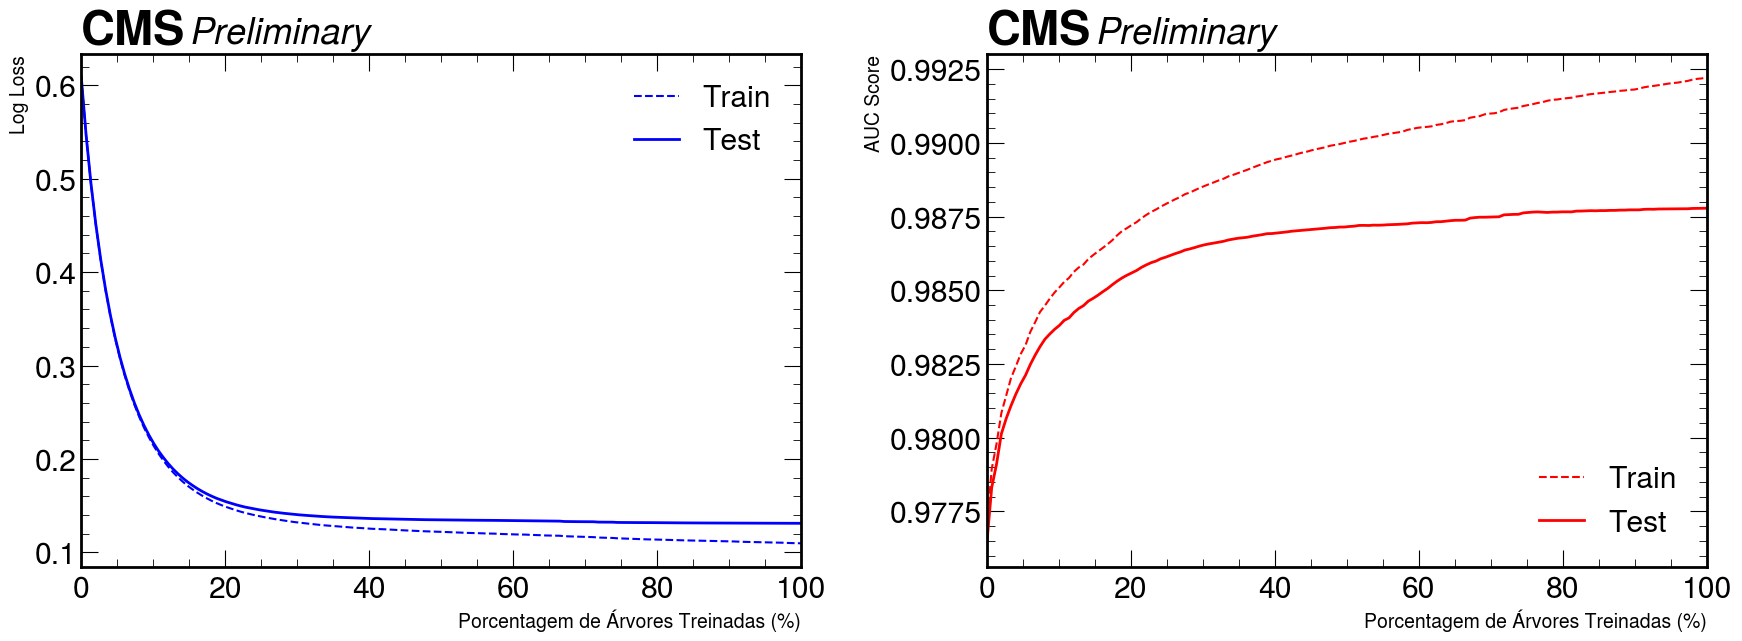

In [29]:
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np
from xgboost import XGBClassifier

# Definir estilo
plt.style.use(hep.style.ROOT)

# 1. Configurar parâmetros (Sem use_label_encoder)
params = grid_search.best_params_.copy()
#params['n_estimators'] = 500
params['eval_metric'] = ["logloss", "auc"]
#params['early_stopping_rounds'] = 20

# 2. Instanciar o modelo
model_monitor = XGBClassifier(
    **params,
    random_state=42
)

# 3. Treinar
print("Treinando modelo com monitoramento...")
model_monitor.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

# 4. Recuperar resultados
results = model_monitor.evals_result()
epochs = len(results['validation_0']['logloss'])

# --- MUDANÇA AQUI: Eixo X em Porcentagem ---
# Cria um array de 0 a 100 distribuído pelo número de épocas (árvores)
x_axis = np.linspace(0, 100, epochs)

# --- PLOTAR EM DOIS GRÁFICOS SEPARADOS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Gráfico 1: Log Loss ---
ax1.plot(x_axis, results['validation_0']['logloss'], label='Train', color='blue', linestyle='--')
ax1.plot(x_axis, results['validation_1']['logloss'], label='Test', color='blue', linewidth=2)
ax1.set_xlabel('Porcentagem de Árvores Treinadas (%)', fontsize=14) # Eixo alterado
ax1.set_ylabel('Log Loss', fontsize=14)
ax1.set_title(f' ', fontsize=16)
ax1.legend()
#ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 100) # Forçar limites
hep.cms.label(loc=0, ax=ax1, data=True, label="Preliminary", rlabel="")

# --- Gráfico 2: AUC ---
ax2.plot(x_axis, results['validation_0']['auc'], label='Train', color='red', linestyle='--')
ax2.plot(x_axis, results['validation_1']['auc'], label='Test', color='red', linewidth=2)
ax2.set_xlabel('Porcentagem de Árvores Treinadas (%)', fontsize=14) # Eixo alterado
ax2.set_ylabel('AUC Score', fontsize=14)
ax2.set_title(f' ', fontsize=16)
ax2.legend(loc='lower right')
#ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 100) # Forçar limites
hep.cms.label(loc=0, ax=ax2, data=True, label="Preliminary", rlabel="")

plt.tight_layout()
plt.savefig("Plots/learning_curve_percentage.png")
print("Plot salvo como: learning_curve_percentage.png")
plt.show()

In [30]:
model_filename = "final_bdt_model.joblib"
joblib.dump(final_bdt, model_filename)
print(f"Modelo salvo: {model_filename}")

Modelo salvo: final_bdt_model.joblib
